In [1]:
import os
# Get the absolute path of the current script
os.getcwd()

'/Users/kamerongano/Documents/GitHub/Fugu_dev/fugu/nscale'

In [2]:
# Section 4.4 determinism
# This section will show 1:1 correspondence between NeuroScale and Fugu SNN simulation
# Add a figure like the 1:1 correspondence figure of Merolla et al., CICC, 2011. 

In [3]:
# network settings
# 100 neurons in total
# leak values of each neuron to +1
# threshold to +10
# each synapse has a 10% probability of being 1, others are 0.
# run 50 time steps.

num_neurons = 200
bias = 1
th = 100
prob_w = 0.2
w = 1
time = 500

'''
num_neurons = 5
bias = 1
th = 4
prob_w = 0.3
w = 1
time = 20
'''

'\nnum_neurons = 5\nbias = 1\nth = 4\nprob_w = 0.3\nw = 1\ntime = 20\n'

In [4]:
import networkx as nx
import numpy as np
import pandas as pd
import random

from fugu.scaffold.scaffold import Scaffold
from fugu.bricks.bricks import Brick
from fugu.backends.snn_backend import snn_Backend

num_neurons = 200
prob_w = 0.2
w = 1
bias = 1
th = 100
time = 500

In [5]:
connec_matrix = []
for i in range(num_neurons):
    connec_vector = []
    for j in range(num_neurons):
        if random.random() < prob_w:
            connec_vector.append(1)
        else:
            connec_vector.append(0)
    connec_matrix.append(connec_vector)
#connec_matrix

In [6]:
class recurrent(Brick):
    def __init__(self, name=None):
        super().__init__()
        self.is_built = False
        self.metadata = {'D':1}  
        self.name = name
    def build(self,
             graph,
             metadata,
             control_nodes,
             input_lists,
             input_codings):

        output_codings = []

        #We also, obviously, need to build the computational portion of our graph
        for i in range(num_neurons):
            graph.add_node(self.name + '_' + str(i),
                           index=i,
                           threshold=th,
                           decay=0.0,
                           bias=bias,
                           p=1.0,
                           potential=0.0
                          )
        for i in range(num_neurons):
            for j in range(num_neurons):
                if connec_matrix[i][j] == 1:
                    graph.add_edge(self.name + '_' + str(i),
                                  self.name + '_' + str(j),
                                  weight=w,
                                  delay=1.0)
        self.is_built=True
        
        # bricks can have more than one output
        output_lists = []
        
        return (graph,
               self.metadata,
                [],
                output_lists,
                output_codings
               )

In [7]:
scaffold = Scaffold()
scaffold.add_brick(recurrent(name='recurrent'), [], output=True)
scaffold.lay_bricks()
#scaffold.summary(verbose=2)

In [8]:
backend = snn_Backend()
backend_args = {}
backend_args['record'] = 'all'
#backend_args['debug_mode'] = True # show the optential at each time
backend.compile(scaffold, backend_args)

In [9]:
result = backend.run(time)
# type(result) # pandas.core.frame.DataFrame

In [10]:
matrix = result.to_numpy()

In [11]:
spike_times = {}
for i in range(num_neurons):
    spike_times[i] = []
for i in matrix:
    spike_times[i[1]].append(int(i[0]))
#spike_times

In [12]:
# record the spikes into spikes_fugu.json file
import json
with open('spikes_fugu.json', 'w') as file:
    json.dump(spike_times, file)

In [13]:
def left_half_circle_marker(radius=1):
    """Create a left half-circle marker without connecting lines."""
    vertices = []
    for angle in np.linspace(np.pi / 2, 3 * np.pi / 2, num=10):  # Points for left half-circle
        vertices.append((radius * np.cos(angle), radius * np.sin(angle)))

    # Define the marker path without closing it
    codes = [Path.MOVETO] + [Path.LINETO] * (len(vertices) - 1)
    return Path(vertices, codes)

def right_half_circle_marker(radius=1):
    """Create a right half-circle marker without connecting lines."""
    vertices = []
    for angle in np.linspace(-np.pi / 2, np.pi / 2, num=10):  # Points for right half-circle
        vertices.append((radius * np.cos(angle), radius * np.sin(angle)))

    # Define the marker path without closing it
    codes = [Path.MOVETO] + [Path.LINETO] * (len(vertices) - 1)
    return Path(vertices, codes)

/Users/kamerongano/Documents/GitHub/Fugu_dev/fugu/nscale/act_fugu.pdf

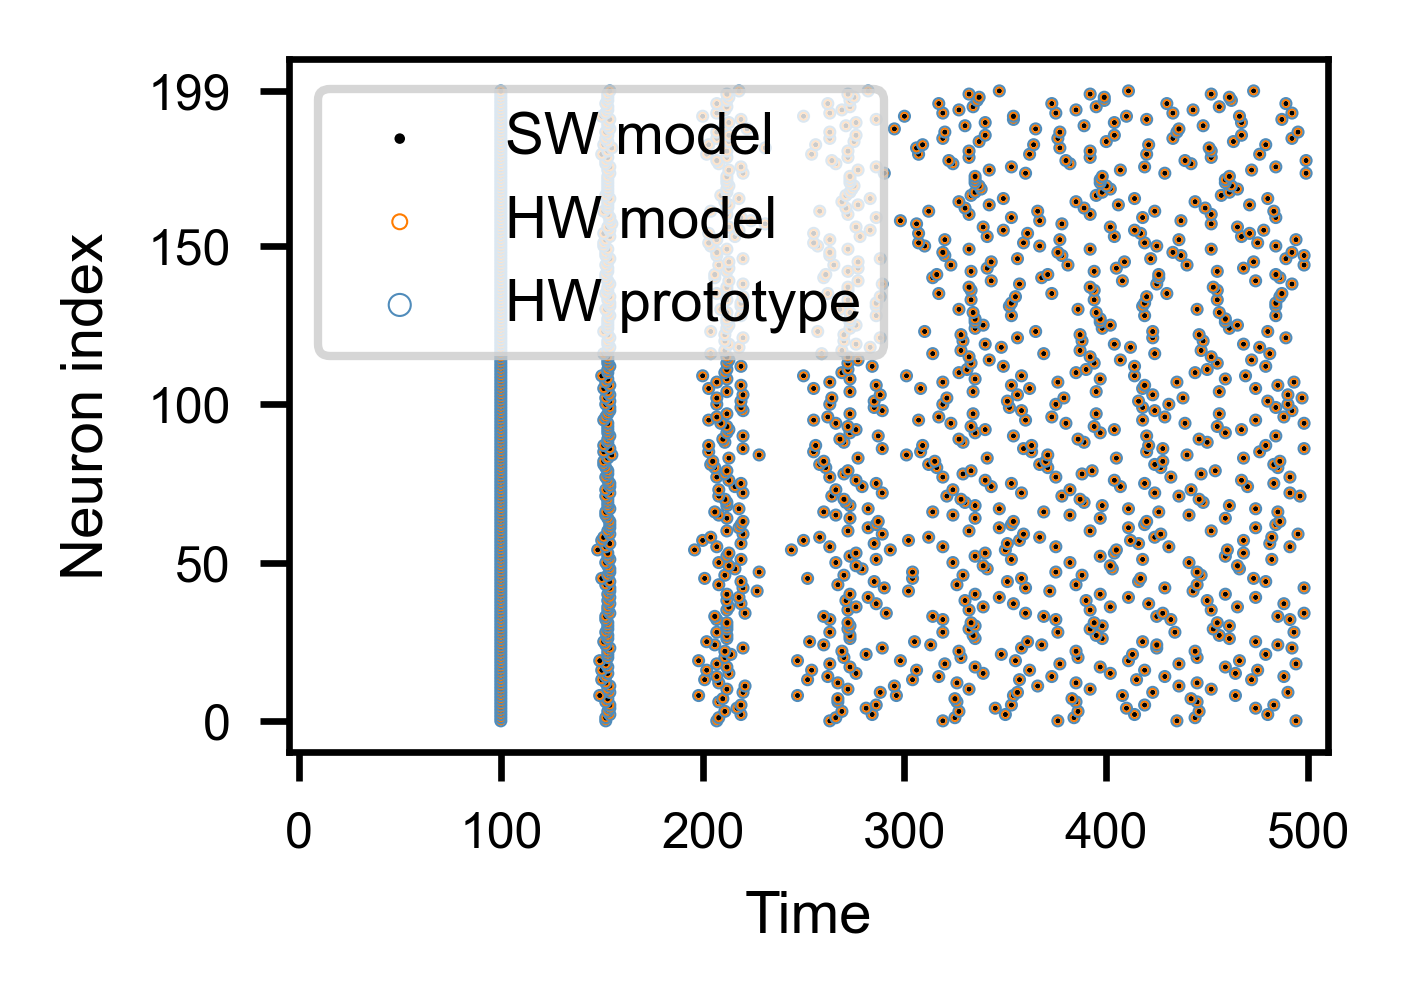

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display, FileLink
from matplotlib.path import Path
from matplotlib.patches import PathPatch
# Convert mm to inches (1 inch = 25.4 mm)
width_inches = ((88) /2) / 25.4  # ≈ 7.09 inches

# If you want the golden ratio for height
height_inches = width_inches / 1.5  # ≈ 4.38 inches


# Apply the seaborn-whitegrid style with custom parameters
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 7,
    'lines.markersize': 2,
    'figure.dpi': 600,
    'figure.figsize': (width_inches, height_inches),
    'lines.linewidth': 1,
    'axes.linewidth': 0.8,
    'axes.grid': False,  # Explicitly turn off grid
    'savefig.bbox': 'tight',
    'savefig.transparent': True,
    'pdf.fonttype': 42  # Ensures fonts are embedded as TrueType
})

# Create the figure and add the axes with the calculated position
fig = plt.figure()  # figsize is already set in rcParams
ax = fig.add_axes([0, 0, 1, 1])

left_marker_path = left_half_circle_marker(radius=0.2)
right_marker_path = right_half_circle_marker(radius=0.2)


#colors = ['#67A1D7','#F38A48']
#colors = ['#2E8B57','#224765']
colors = ['#508CBB','#Ff7c00','#78a741']

# Plot each neuron's spike times with dots and hollow circles
for i, (neuron, times) in enumerate(spike_times.items()):
    # dot and two half circles
    #plt.scatter(times, [i] * len(times), color='black', s=1.8, marker='o', label='Fugu' if i == 0 else "")  # Filled black dots
    #plt.scatter(times, [i] * len(times), marker=left_marker_path, edgecolor=to_rgba(colors[1]), facecolor='none', s=23, label='ACT' if i == 0 else "")  # Left half-circle
    #plt.scatter(times, [i] * len(times), marker=right_marker_path, edgecolor=colors[0], facecolor='none', s=23, label='FPGA' if i == 0 else "")  # Right half-circle
    
    # dot and circle and cross
    
    #plt.scatter(times, [i] * len(times), marker='o', edgecolor=to_rgba(colors[0]), facecolor='none', s=27, label='ACT' if i == 0 else "")
    #plt.scatter(times, [i] * len(times), marker='x', color=to_rgba(colors[1]), s=16, label='FPGA' if i == 0 else "")  # Right half-circle# Left half-circle
    #plt.scatter(times, [i] * len(times), color='black', s=1.8, marker='o', label='Fugu' if i == 0 else "")  # Filled black dots
    plt.scatter(times, [i] * len(times), color='black', s=0.4, marker='o', edgecolors='none', label='SW model' if i == 0 else "")  # Filled black dots
    plt.scatter(times, [i] * len(times), marker='o', edgecolor=to_rgba(colors[1]), facecolor='none', s=0.8, linewidth=0.25, label='HW model' if i == 0 else "")  # Right half-circle# Left half-circle
    plt.scatter(times, [i] * len(times), marker='o', edgecolor=to_rgba(colors[0]), facecolor='none', s=1.75, linewidth=0.25,label='HW prototype' if i == 0 else "")
       

# Customize the plot
plt.xlabel('Time')
plt.ylabel('Neuron index')

# Select specific y-ticks (e.g., every 50th neuron)
selected_indices = [0, 50, 100, 150, 199]  # Using 199 instead of 200
plt.yticks(selected_indices, selected_indices)  # Use indices as labels

#plt.xticks([])
#plt.yticks([])


# Set x-axis limits for better visualization
plt.xlim(-5, time+10)

# Add legend
plt.legend(prop={'family': 'Arial'}, loc='upper left', markerscale=2) 
 

# Remove grid and lines
plt.grid(False)

# Show the plot
#plt.show()

# Save the figure to a PDF file
with PdfPages('act_fugu.pdf') as pdf:
    # This line will save the current figure to the PDF
    pdf.savefig(bbox_inches='tight')

# Display the saved PDF file
display(FileLink('act_fugu.pdf'))

In [15]:

# neuron info
for i, neuron in enumerate(sorted(scaffold.graph.nodes)):
    print(str(neuron) + " | " + str(scaffold.graph.nodes[neuron]))

# synapse info
for i, synapse in enumerate(scaffold.graph.edges):
    print(str(synapse) + " | " + str(scaffold.graph.edges[synapse]))


recurrent_0 | {'index': 0, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 0}
recurrent_1 | {'index': 1, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 1}
recurrent_10 | {'index': 10, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 10}
recurrent_100 | {'index': 100, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 100}
recurrent_101 | {'index': 101, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 101}
recurrent_102 | {'index': 102, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 102}
recurrent_103 | {'index': 103, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 103}
recurre

In [16]:
def gen_json(graph, timestamps, path):
    # json file
    network_json = {}
    network_json['ticks'] = timestamps
    network_json['neuron_dict'] = {}
    network_json['synapse_dict'] = {}
    
    for i, neuron in enumerate(sorted(graph.nodes)):
        neuron_info = graph.nodes[neuron]
        network_json['neuron_dict'][str(neuron_info['neuron_number'])] = {"fan-in": [],
                                                                     "fan-out": [],
                                                                     "th": neuron_info['threshold'],
                                                                     "leak": 0.0,
                                                                     "bias": 0.0,
                                                                     "refractory period": 0,
                                                                     "prob": neuron_info['p']
                                                                    }
        if 'leakage_constant' in neuron_info:
            network_json['neuron_dict'][str(neuron_info['neuron_number'])]['leak'] = neuron_info['leakage_constant']
        if 'bias' in neuron_info:
            network_json['neuron_dict'][str(neuron_info['neuron_number'])]['bias'] = neuron_info['bias'] 
        if 'refractory_period' in neuron_info:
            network_json['neuron_dict'][str(neuron_info['neuron_number'])]['refractory_period'] = neuron_info['refractory_period']    
    
    for i, synapse in enumerate(graph.edges):
        pre_neuron = graph.nodes[synapse[0]]['neuron_number']
        post_neuron = graph.nodes[synapse[1]]['neuron_number']
        network_json['neuron_dict'][str(post_neuron)]['fan-in'].append(pre_neuron)
        network_json['neuron_dict'][str(pre_neuron)]['fan-out'].append(post_neuron)
        if str(post_neuron) not in network_json['synapse_dict']:
            network_json['synapse_dict'][str(post_neuron)] = {}
        if str(pre_neuron) not in network_json['synapse_dict'][str(post_neuron)]:
            network_json['synapse_dict'][str(post_neuron)][str(pre_neuron)] = {}
        network_json['synapse_dict'][str(post_neuron)][str(pre_neuron)][str(len(network_json['synapse_dict'][str(post_neuron)][str(pre_neuron)]))] = {'fixed-wt': graph.edges[synapse]['weight'],
                                                                                                                                                      'delay': graph.edges[synapse]['delay']}
    with open(path, 'w') as f:
        json.dump(network_json, f) 

In [17]:
gen_json(scaffold.graph, time, "network.json")